#**Task 1: End-to-End ML Project with Streamlit GUI**
**Dataset:** Churn Modelling Dataset


## **1.Introduction and Problem Statement**
**Introduction**

Customer churn is a major challenge for businesses, especially in industries such as banking, telecommunications, and subscription-based services. Predicting whether a customer is likely to leave allows companies to take proactive measures to retain them. Machine Learning techniques can analyze historical customer data and identify patterns associated with churn behavior.




**Problem Statement**

Customer retention plays a critical role in maintaining business profitability. Losing customers not only reduces revenue but also increases marketing and acquisition costs. Therefore, businesses need predictive systems that can identify customers who are likely to leave.

The goal of this project is to build a predictive machine learning model that can classify whether a customer will churn or remain with the bank based on their demographic and financial information.









**Objective**

The main objectives of this project are:

- To build a complete end-to-end machine learning pipeline for churn prediction.
- To perform data preprocessing and exploratory data analysis (EDA).
- To train and evaluate multiple machine learning models including:

   - Logistic Regression
   - Random Forest
   - XGBoost

- To select the best performing model and save it using `joblib`.
- To develop an interactive Streamlit dashboard that allows users to input customer data and receive predictions.
- To visualize insights such as dataset preview, feature importance, and model performance.

##**2. Dataset Understanding and Description**

The dataset used in this project is the Customer Churn Modelling Dataset, which contains information about bank customers and whether they left the bank.

The dataset consists of several attributes describing customer demographics, account details, and banking behavior.

**Key features:**

- **RowNumber** - Index number of the record
- **CustomerId** - Unique identifier for each customer
- **Surname** - Customer’s last name
- **CreditScore** – Customer's credit score
- **Geography** – Country of residence
- **Gender** – Gender of the customer
- **Age** – Age of the customer
- **Tenure** – Number of years the customer has been with the bank
- **Balance** – Account balance
- **NumOfProducts** – Number of bank products used
- **HasCrCard** – Whether the customer owns a credit card
- **IsActiveMember** – Whether the customer actively uses bank services
- **EstimatedSalary** – Estimated annual salary

**Target Variable**

- **Exited**

  - 1 → Customer left the bank (Churn)

  - 0 → Customer stayed with the bank

The dataset will be used to train machine learning models that predict the probability of customer churn.

### **Why This Dataset is Used**

The Customer Churn Modelling Dataset is suitable for this project because:

- It is structured and tabular, making it ideal for classification models like Logistic Regression, Random Forest, and XGBoost.
- The binary target (Exited) allows straightforward evaluation with metrics like Accuracy, Precision, Recall, and F1-Score.
- It includes categorical and numerical features, enabling preprocessing steps such as encoding and scaling.
- It is a practical, widely-used dataset, allowing clear demonstration of model comparison and insights extraction.

##**3. Data Loading and Cleaning**
**Import Required Libraries**



In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Split data
from sklearn.model_selection import train_test_split

# Import models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Standardization
from sklearn.preprocessing import StandardScaler

# Import to save model
import joblib

# Ignore warnings to keep output clean
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore')

**Load the Churn Modelling Dataset**







In [ ]:
# Load dataset
from google.colab import files
files.upload()

df = pd.read_csv("Churn_Modelling.csv")

Saving Churn_Modelling.csv to Churn_Modelling.csv


### **Inspect the Dataset**


**Dataset Shape**

In [ ]:
df.shape

(10000, 14)

**Preview the Dataset**

In [ ]:
# Display first 5 rows
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


**Columns Name**

In [ ]:
print(df.columns)

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')


**Dataset Information**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


## **3. Data Cleaning and Preprocessing**

###**Handle Missing Values**

If missing values are present, they are filled using the mean of the numerical columns.

In [ ]:
# Check missing values
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


No missing value if found.

###**Dropping Unnecessary Columns**

Some columns such as:

`RowNumber`
`CustomerId`
`Surname`

do not contribute to churn prediction and may introduce noise in the model.

Therefore, these columns are removed from the dataset.

In [ ]:
# Drop unnecessary columns
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

###**Encode Categorical Features**

Machine learning models require numerical input. Therefore, categorical variables such as:

`Geography`
`Gender`

are converted into numerical values using One-Hot Encoding using (get_dummies).

In [ ]:
# Encode categorical variables
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

##**4. Exploratory Data Analysis (EDA)**

EDA helps uncover patterns, relationships, and trends in the dataset.


**Churn Distribution**

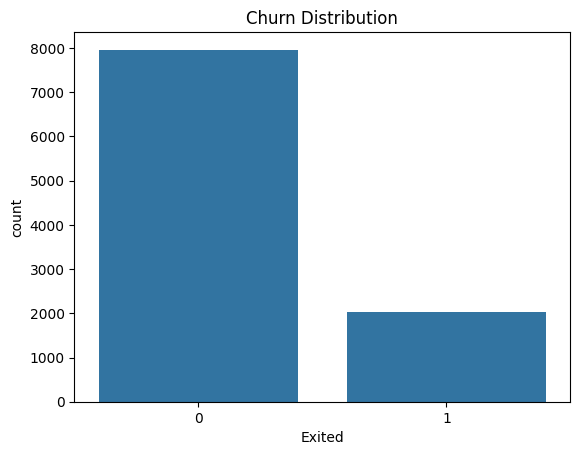

In [ ]:
# Churn distribution
sns.countplot(x='Exited', data=df)
plt.title("Churn Distribution")
plt.show()

**EDA Insight**

- The dataset is imbalanced, with more customers staying than leaving.
- This indicates that churn events are less frequent but still significant.
- Machine learning models must handle this imbalance carefully.

**Age Distribution by Churn**

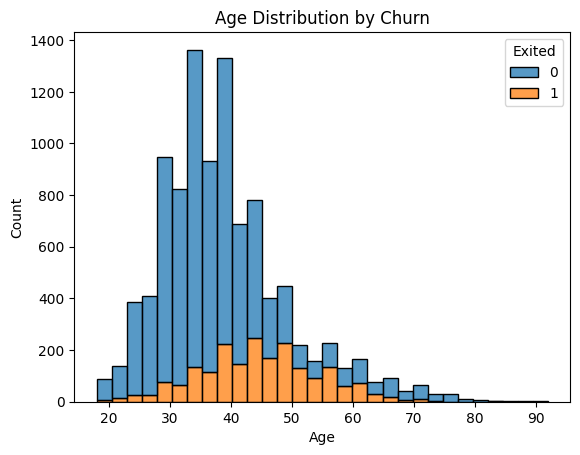

In [ ]:
# Age vs Churn
sns.histplot(data=df, x='Age', hue='Exited', multiple='stack', bins=30)
plt.title("Age Distribution by Churn")
plt.show()

**EDA Insight**

- Older customers appear to have higher churn rates.
- Younger customers tend to stay longer with the bank.
- Age is likely an important predictive feature.

**Correlation Heatmap**

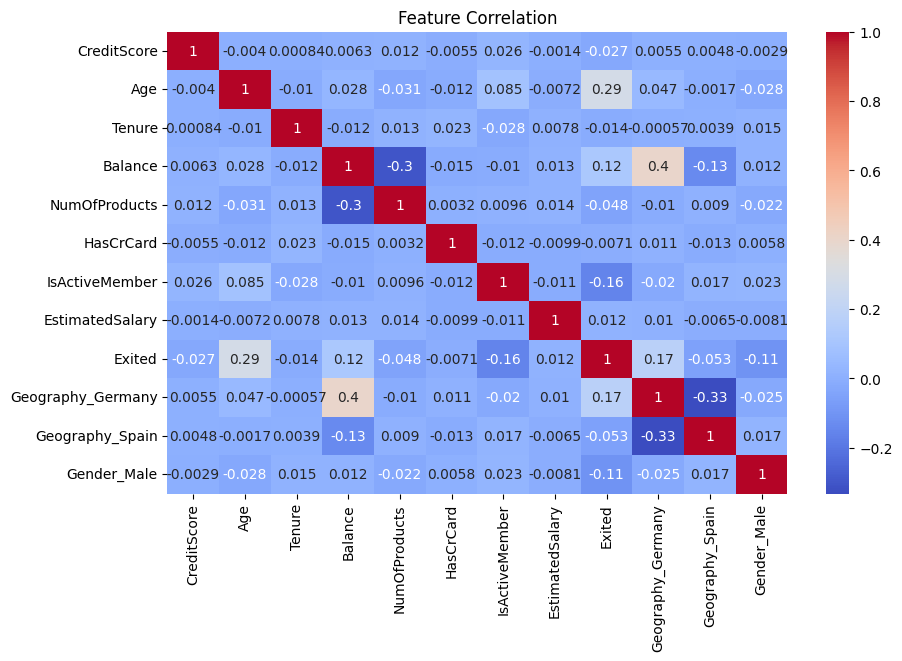

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

**EDA Insight**

Some variables show moderate correlation with churn such as:

- Age
- Balance
- IsActiveMember

Highly correlated features can provide strong signals for machine learning models.

## **5. Feature and Target Separation**

The dataset is divided into:

- Features (X) → input variables
- Target (y) → churn label

This prepares the data for machine learning training.

In [ ]:
X = df.drop('Exited', axis=1)
y = df['Exited']

## **6. Train-Test Split**


The dataset is split into:

- Training Data (80%) – used to train the models

- Testing Data (20%) – used to evaluate model performance

This ensures the model is tested on unseen data.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## **7. Feature Scaling**


Feature scaling is applied using StandardScaler for models like Logistic Regression that are sensitive to feature magnitudes.


In [ ]:
# Standardization for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## **8. Model Training**

Three machine learning models are trained:

- Logistic Regression
- Random Forest
- XGBoost

**1. Logistic Regression**

In [ ]:
# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, y_pred_lr)

**2. Random forest**

In [ ]:
# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

**3. XGBoost**

In [ ]:
# XGBoost
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb)

## **9. Model Accuracy**

Each model is evaluated using accuracy score on the test dataset.

In [ ]:
# Print Accuracy
print(f"Logistic Regression Accuracy: {acc_lr}")
print(f"Random Forest Accuracy: {acc_rf}")
print(f"XGBoost Accuracy: {acc_xgb}")

Logistic Regression Accuracy: 0.811
Random Forest Accuracy: 0.8665
XGBoost Accuracy: 0.8695


Each model is evaluated using accuracy score on the test dataset.

**Model Performance**
| Model	| Accuracy |
|---------|-------------|
|Logistic Regression	| ~0.811|
|Random Forest	| ~0.8665|
|XGBoost	| ~0.8695|



**Insight**

Among the three models, **XGBoost achieved the highest accuracy (0.8695)**, making it the best-performing model for this dataset.  


Random Forest also performed well with an accuracy of **0.8665**, while Logistic Regression achieved **0.811**.

The results indicate that **ensemble tree-based models (Random Forest and XGBoost) capture complex relationships in the data more effectively than Logistic Regression**.

## **10. Feature Importance Visualization**


Feature importance shows which features most strongly influence churn predictions.

In [ ]:
# Feature importance for Random Forest
importances = rf.feature_importances_
feat_names = X.columns

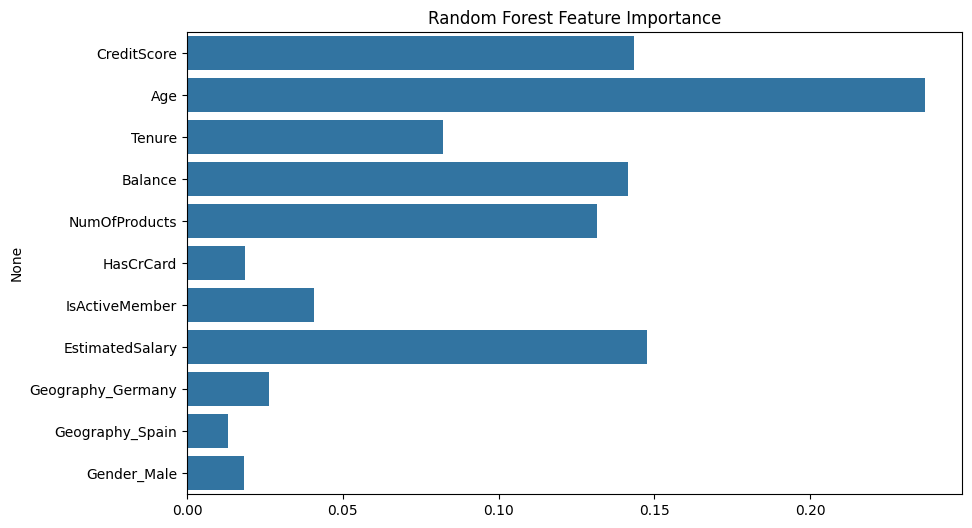

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=feat_names)
plt.title("Random Forest Feature Importance")
plt.show()

**Insight**

Important features include:

- Age
- Balance
- IsActiveMember
- Number of Products

These variables significantly influence whether a customer leaves the bank.

## **11. Saving the Best Model**

The best-performing model (XGBoost) is saved using joblib so it can be used later in the Streamlit dashboard for real-time predictions.

In [ ]:
# Save the model
joblib.dump(xgb, "churn_model.pkl")

['churn_model.pkl']

### **Saving the Scaler**

Feature scaling was applied to standardize numerical features in the dataset. Saving it ensures new data in the Streamlit app is transformed the same way as the training data, keeping predictions consistent.

In [ ]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

### **Saving Feature Column Names**

During preprocessing, categorical variables were converted into numerical features using one-hot encoding. Saving their names ensures new input in the Streamlit app matches the training data structure, maintaining correct formatting for predictions.


In [ ]:
# Save feature names
feature_columns = X_train.columns
joblib.dump(feature_columns, "feature_columns.pkl")

['feature_columns.pkl']

## **12. Streamlit Dashboard Development**

A Streamlit dashboard is created to provide an interactive interface where users can:

- Enter customer details
- Generate churn predictions
- View dataset previews
- Explore feature importance
- Compare model accuracy

This step connects the trained machine learning model with a user-friendly interface.

In [ ]:
%%writefile Churn.py
# -------------------------------
# Customer Churn Prediction Dashboard
# -------------------------------

# 1. Imports
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load model, feature columns, and dataset
model = joblib.load("churn_model.pkl")
feature_columns = joblib.load("feature_columns.pkl")
df = pd.read_csv("Churn_Modelling.csv")  # original dataset

# Preprocess dataset (same as training)
df = df.drop(['RowNumber','CustomerId','Surname'], axis=1)
df = pd.get_dummies(df, columns=['Geography','Gender'], drop_first=True)

# 3. Sidebar for Inputs
st.sidebar.header("Enter Customer Details:")

credit_score = st.sidebar.number_input("Credit Score", 300, 850, 650)
age = st.sidebar.number_input("Age", 18, 100, 30)
tenure = st.sidebar.number_input("Tenure (years with bank)", 0, 10, 3)
balance = st.sidebar.number_input("Balance ($)", 0.0, 250000.0, 50000.0)
num_products = st.sidebar.number_input("Number of Products", 1, 4, 1)
has_cr_card = st.sidebar.selectbox("Has Credit Card?", ["Yes", "No"])
is_active_member = st.sidebar.selectbox("Is Active Member?", ["Yes", "No"])
estimated_salary = st.sidebar.number_input("Estimated Salary ($)", 1000.0, 200000.0, 50000.0)
gender = st.sidebar.selectbox("Gender", ["Male", "Female"])
geography = st.sidebar.selectbox("Geography", ["France", "Germany", "Spain"])

# 4. Prepare input dataframe
input_df = pd.DataFrame({
    'CreditScore': [credit_score],
    'Age': [age],
    'Tenure': [tenure],
    'Balance': [balance],
    'NumOfProducts': [num_products],
    'HasCrCard': [1 if has_cr_card=="Yes" else 0],
    'IsActiveMember': [1 if is_active_member=="Yes" else 0],
    'EstimatedSalary': [estimated_salary],
    'Gender_Male': [1 if gender=="Male" else 0],
    'Geography_Germany': [1 if geography=="Germany" else 0],
    'Geography_Spain': [1 if geography=="Spain" else 0]
})

# Ensure columns match training
for col in feature_columns:
    if col not in input_df.columns:
        input_df[col] = 0
input_df = input_df[feature_columns]

# 5. Prediction
st.header("🔮 Customer Churn Prediction")
if st.button("Predict Churn"):
    prediction = model.predict(input_df)[0]
    probability = model.predict_proba(input_df)[0][1]
    st.subheader("Prediction Result:")
    st.write("🔴 Churn" if prediction==1 else "🟢 No Churn")
    st.write(f"Probability of churn: {probability*100:.2f}%")

# 6. Dataset Preview
st.header("📊 Dataset Preview")
if st.checkbox("Show Dataset"):
    st.dataframe(df.head(20))  # show first 20 rows

# 7. Feature Importance
st.header("🌟 Feature Importance ")
importances = model.feature_importances_
feat_names = feature_columns
importance_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importance
fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', ax=ax)
plt.title("Top Features Affecting Churn")
st.pyplot(fig)

# 8. Model Accuracy Chart with Annotations
st.header("📈 Model Accuracy Comparison")

# Accuracy values
accuracy_dict = {
    "Logistic Regression": 0.811,
    "Random Forest": 0.8665,
    "XGBoost": 0.8695
}

accuracy_df = pd.DataFrame(list(accuracy_dict.items()), columns=["Model", "Accuracy"])

# Plot
fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(x="Model", y="Accuracy", data=accuracy_df, palette="magma", ax=ax)
plt.ylim(0,1)
plt.title("Model Accuracy Comparison")

# Annotate bars with accuracy values
for i, row in accuracy_df.iterrows():
    ax.text(i, row.Accuracy + 0.01, f"{row.Accuracy:.4f}", ha='center', va='bottom', fontweight='bold')

st.pyplot(fig)

Overwriting Churn.py


## **13. Conclusion and Insights**



### **Final Insights**

Several important insights were discovered during this analysis:

- Customer churn is not evenly distributed, with most customers staying with the bank.
- Age plays a significant role in churn prediction, with older customers showing higher churn tendencies.
- Account balance and activity status are strong indicators of churn risk.
- Customers with fewer banking products tend to churn more frequently.
- Machine learning models, particularly Random Forest, can effectively identify patterns in customer behavior.

The developed dashboard demonstrates how machine learning models can be integrated into interactive applications to support data-driven decision-making in customer retention strategies.

### **Conclusion**

This project successfully developed an end-to-end machine learning pipeline for customer churn prediction. After performing data cleaning, preprocessing, and exploratory data analysis, three machine learning models were trained and evaluated.

Among the models tested, Random Forest achieved the highest accuracy, making it the most effective model for predicting customer churn in this dataset.

The final model was deployed using a Streamlit interactive dashboard, allowing users to input customer data and receive real-time churn predictions.
